<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/River_Flow_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

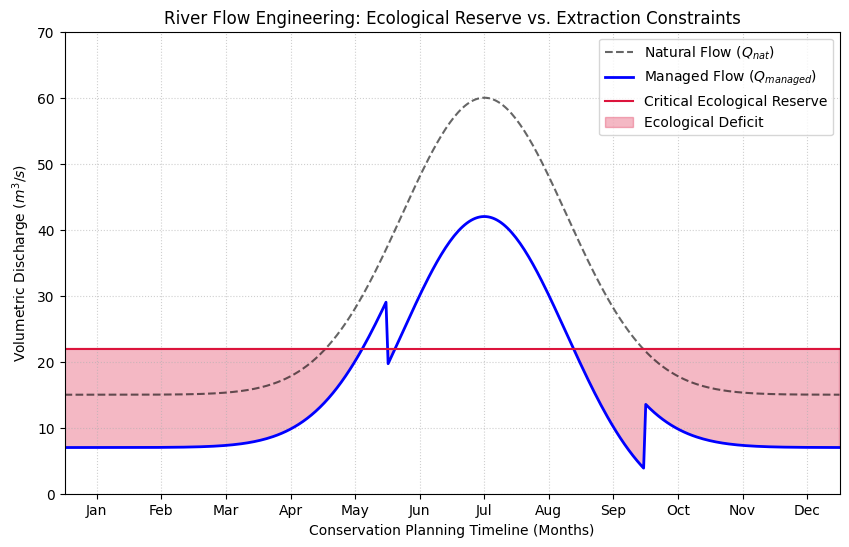

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Time Array (12 Months of a Conservation Year)
months = np.array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
t = np.linspace(0, 12, 365)  # Daily sampling for smooth curves

# 2. Mathematical Functions for River Volumetric Flow
# Baseflow + a Gaussian curve simulating peak seasonal rainfall/snowmelt
natural_discharge = 15 + 45 * np.exp(-((t - 6.5) / 1.8)**2)  # Peak in July

# Engineering Constraints for Conservation
human_extraction = np.where((t > 5) & (t < 9), 18, 8)  # Higher demand in dry/summer months
managed_discharge = natural_discharge - human_extraction

# Environmental Baseline (e.g., 20% of mean natural flow must remain for wildlife)
eco_reserve_line = np.full_like(t, 22.0)

# 3. Calculate Cumulative Deficit Volumes via Numerical Integration
# Delta t in seconds per day (86400)
dt = (12 * 30.5 * 86400) / 365
below_reserve = managed_discharge < eco_reserve_line

# 4. Plotting the Hydrograph
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t, natural_discharge, 'k--', label='Natural Flow ($Q_{nat}$)', alpha=0.6)
plt.plot(t, managed_discharge, 'b-', label='Managed Flow ($Q_{managed}$)', linewidth=2)
plt.axhline(22.0, color='crimson', linestyle='-', label='Critical Ecological Reserve')

# Visual Anchors for Deficit Regions
plt.fill_between(t, managed_discharge, eco_reserve_line,
                 where=below_reserve, color='crimson', alpha=0.3, label='Ecological Deficit')

# Formatting Axes
plt.xticks(ticks=np.linspace(0.5, 11.5, 12), labels=months)
plt.xlim(0, 12)
plt.ylim(0, 70)
plt.xlabel('Conservation Planning Timeline (Months)')
plt.ylabel('Volumetric Discharge ($m^3/s$)')
plt.title('River Flow Engineering: Ecological Reserve vs. Extraction Constraints')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()
